### importing libraries
#### importing LogisticRegression and accuracy score

In [118]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### importing the csv file of the training and testing dataset

In [147]:
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')
y_train = y_train.squeeze()
y_test = y_test.squeeze()
print(X_train.shape)
print(y_train.shape)

(3212, 29)
(3212,)


#### cleaning data due to data leakage.

In [148]:
cols_to_drop = ['map_pressure', 'pulse_pressure']
X_train_clean = X_train.drop(columns=cols_to_drop)
X_test_clean = X_test.drop(columns=cols_to_drop)

### initialising that the model we are doing is logistic regresssion

In [120]:
model = LogisticRegression()

### telling the model to study the training datasets

In [149]:
model.fit(X_train_clean, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### to predict y(hypertension) using a dataset that is new to the model

In [150]:
y_pred = model.predict(X_test_clean)

In [151]:
accuracy_score(y_test, y_pred)

0.7484433374844334

In [152]:
print(y_train.value_counts())

hypertension
0    2422
1     790
Name: count, dtype: int64


### importing lib from sklearn

In [153]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [154]:
print(confusion_matrix(y_test, y_pred))

[[563  43]
 [159  38]]


In [155]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       606
           1       0.47      0.19      0.27       197

    accuracy                           0.75       803
   macro avg       0.62      0.56      0.56       803
weighted avg       0.70      0.75      0.71       803



In [156]:
print(roc_auc_score(y_test, y_pred))

0.5609681526528286


In [157]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [160]:
y_prob = model.predict_proba(X_test_clean)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

### plotting the ROC curve

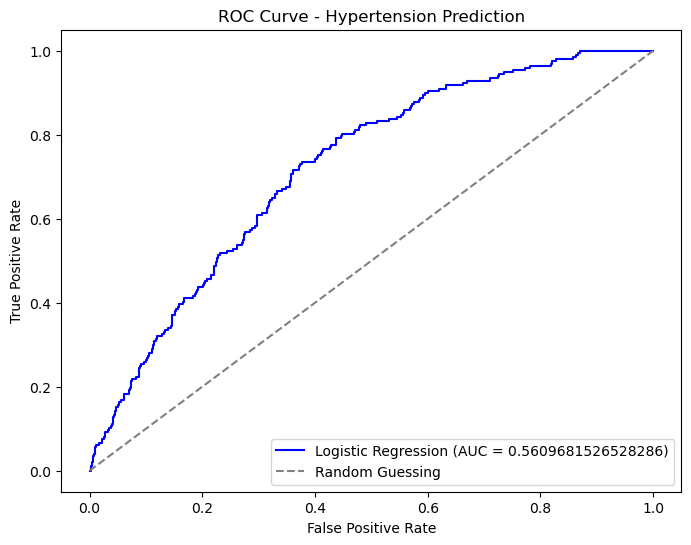

In [161]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='Logistic Regression (AUC = 0.5609681526528286)')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Hypertension Prediction')
plt.legend()
plt.show()

### place the coefficients into a list and then assigning it to feature based on column

In [163]:
coefficients = pd.Series(model.coef_[0], index=X_train_clean.columns)
coefficients_sorted = coefficients.sort_values()

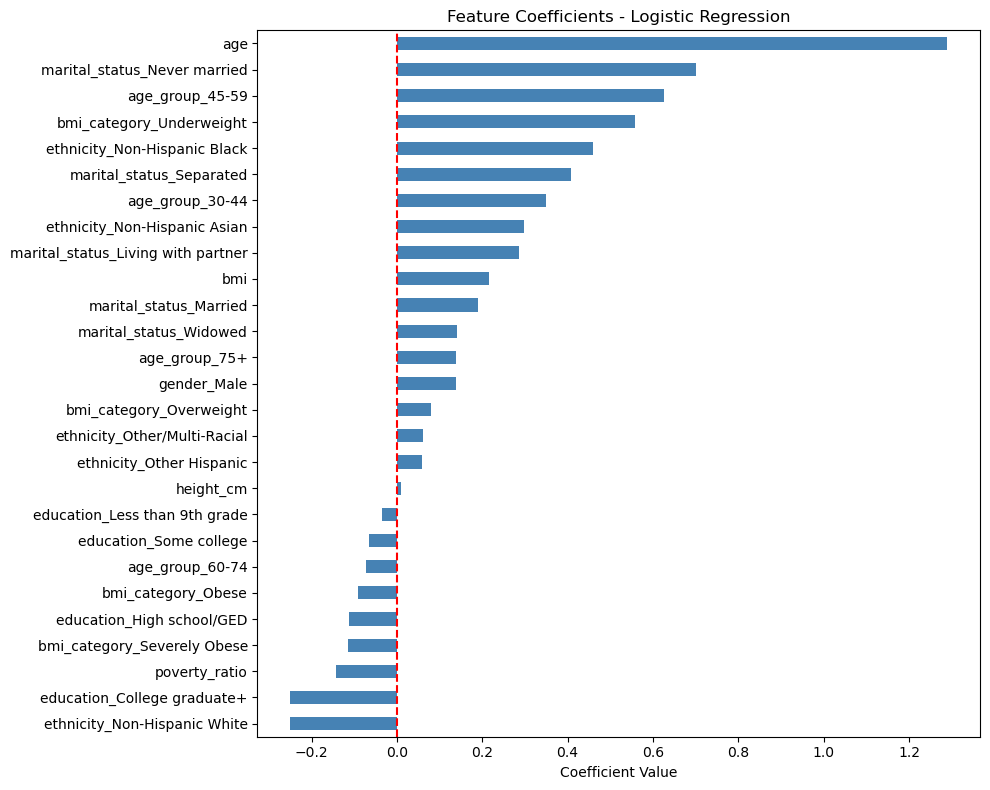

In [164]:
plt.figure(figsize=(10, 8))
coefficients_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Coefficients - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

#### Training using XGBoost

In [175]:
%pip install xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)


Note: you may need to restart the kernel to use updated packages.


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [166]:
# XGBoost predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

#### Printing the metrics for the XGBoost model

In [179]:
print(accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(roc_auc_score(y_test, y_pred_proba_xgb))

0.7347447073474471
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       606
           1       0.41      0.19      0.26       197

    accuracy                           0.73       803
   macro avg       0.59      0.55      0.55       803
weighted avg       0.69      0.73      0.70       803

0.7215828181802951


#### Plotting the Feature importance score 

<Figure size 1000x800 with 0 Axes>

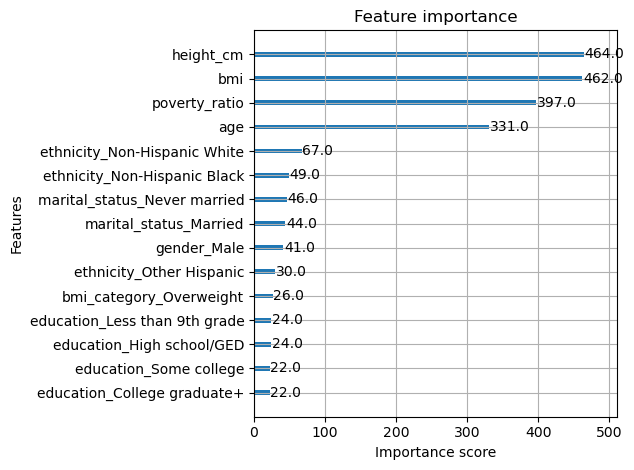

In [181]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=15)
plt.tight_layout()
plt.show()

#### plottinig metrics scores, logistic vs XGBoost model

                          Logistic Regression  XGBoost
Metric                                                
Accuracy                                 0.75     0.73
Precision (hypertensive)                 0.47     0.41
Recall (hypertensive)                    0.19     0.19
F1 (hypertensive)                        0.27     0.26
AUC-ROC                                  0.56     0.72


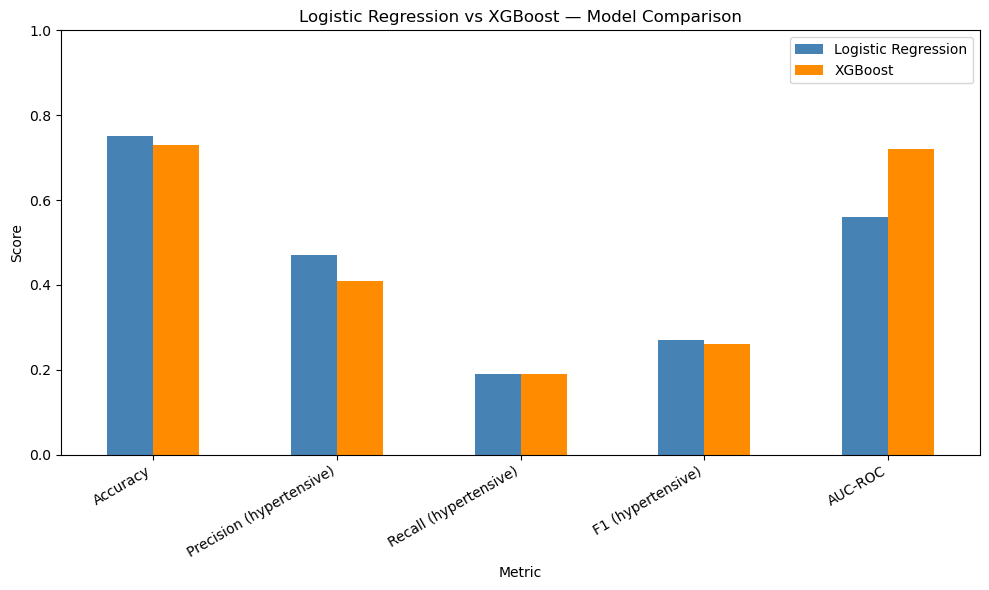

In [183]:
comparison = {
    'Metric': ['Accuracy', 'Precision (hypertensive)', 'Recall (hypertensive)', 'F1 (hypertensive)', 'AUC-ROC'],
    'Logistic Regression': [0.75, 0.47, 0.19, 0.27, 0.56],
    'XGBoost': [0.73, 0.41, 0.19, 0.26, 0.72]
}

df_comparison = pd.DataFrame(comparison)
df_comparison.set_index('Metric', inplace=True)
print(df_comparison)

df_comparison.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'darkorange'])
plt.title('Logistic Regression vs XGBoost — Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

#### plotting the ROC curves, Logistic vs XGBoost model

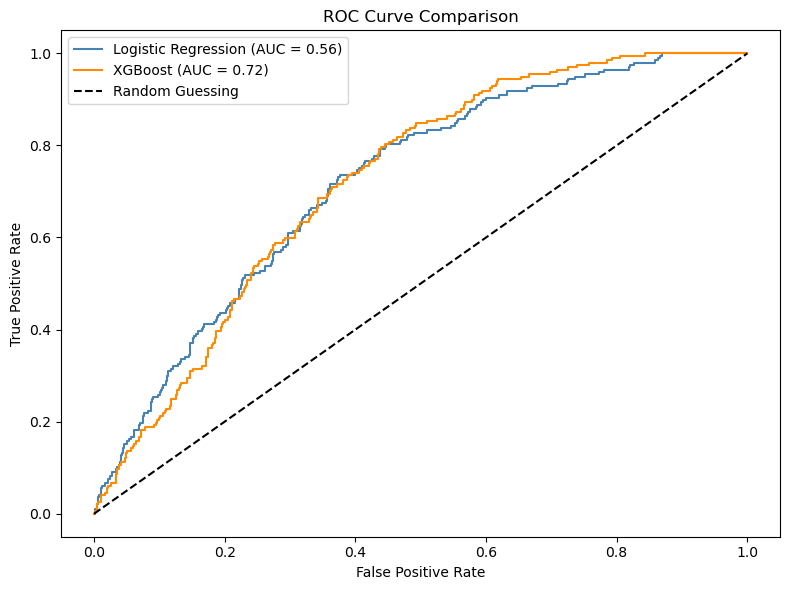

In [185]:
y_prob_logreg = model.predict_proba(X_test_clean)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_clean)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_logreg)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = 0.56)', color='steelblue')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = 0.72)', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

### Summary

##### This notebook highlights the performance of XGBoost model vs the logistic regression model i did in week 4, with a few changes.
##### The changes i made wass that i dropped features: MAP and Pulse Pressure due to data leakage. Due to this changes the plots and the scores now changed and have a more honest result.
##### The XGBoost regression model shows a quite significantly higher AUC-ROC than the logistic regression model. However, the logistic regression model still beats the XGBoost on Accuracy, Precision and F1 - just a tiny bit higher. Nonetheless, the most important reading is the AUC-ROC reading as in clinical setting, random guessing is really dangerous.
##### XGBoost is selected as the primary model for the fairness audit in Weeks 8-10. Despite marginally lower accuracy, its AUC-ROC of 0.72 compared to logistic regression's 0.56 demonstrates it is genuinely learning patterns in the data rather than exploiting class imbalance. A model that barely outperforms random guessing is not suitable for fairness evaluation.
##### Both models struggle with recall for the hypertensive class (0.19), meaning 81% of actual hypertension cases are missed. This is driven by class imbalance in the dataset — 606 non-hypertensive vs 197 hypertensive patients. This will be addressed in Week 6 during model refinement.
##### Notably, XGBoost identified height, BMI, and poverty ratio as the top predictors — diverging from logistic regression which ranked age as the dominant feature. The presence of demographic features such as ethnicity and gender in XGBoost's top predictors raises fairness concerns that will be formally investigated in the audit phase.